#### 1) Importing Necessary Libraries:

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import TransformerMixin, BaseEstimator

from sklearn.cluster import KMeans

#### 2) Loading Dataset:

In [2]:
housing = fetch_california_housing()

##### Data Description:

In [15]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
print(housing.data.shape)

(20640, 8)


In [4]:
print(housing.target.shape)

(20640,)


In [5]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [6]:
print(housing.target_names)

['MedHouseVal']


In [7]:
# Features and Target in Dataframes:

X = pd.DataFrame(data= housing.data, columns= housing.feature_names)
y = pd.DataFrame(data= housing.target, columns= housing.target_names)

In [8]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
y.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [10]:
print(X.shape)
print(y.shape)

(20640, 8)
(20640, 1)


In [12]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [13]:
y.describe()

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


#### 3) Data Cleaning and Features Transformations:

##### 1) Missing Value Handling:

In [16]:
X.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

There are no Missing Values in Dataset.

##### 2) MedInc:

In [19]:
X['MedInc'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: MedInc, dtype: float64

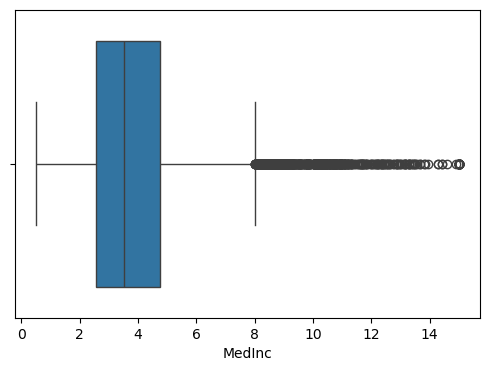

In [20]:
plt.figure(figsize= (6,4))
sns.boxplot(data= X, x= 'MedInc')
plt.show()

- Seems like there are a lot of Outliers in 'MedInc' feature.

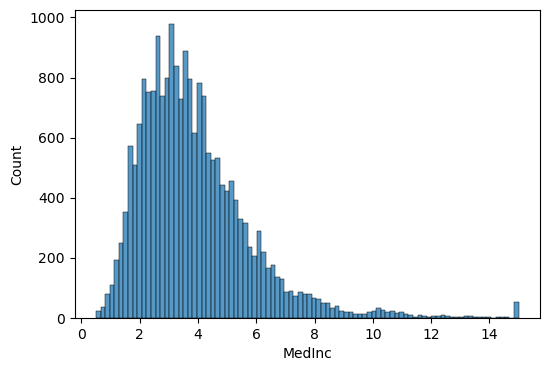

In [21]:
plt.figure(figsize= (6,4))
sns.histplot(data= X, x= 'MedInc')
plt.show()

- Distribution is Mostly Normal with a Long Right Tail showing Presence of Outliers.

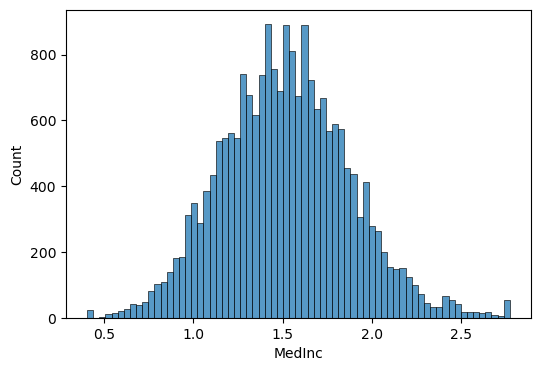

In [22]:
plt.figure(figsize= (6,4))
sns.histplot(data= X['MedInc'].apply(np.log1p))
plt.show()

In [23]:
medinc_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

In [24]:
# Preprocessor:

preprocessor = ColumnTransformer([
    ('Median_Income', medinc_pipeline, ['MedInc'])
])

##### 3) HouseAge:

In [26]:
X['HouseAge']

0        41.0
1        21.0
2        52.0
3        52.0
4        52.0
         ... 
20635    25.0
20636    18.0
20637    17.0
20638    18.0
20639    16.0
Name: HouseAge, Length: 20640, dtype: float64

In [27]:
X['HouseAge'].describe()

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: HouseAge, dtype: float64

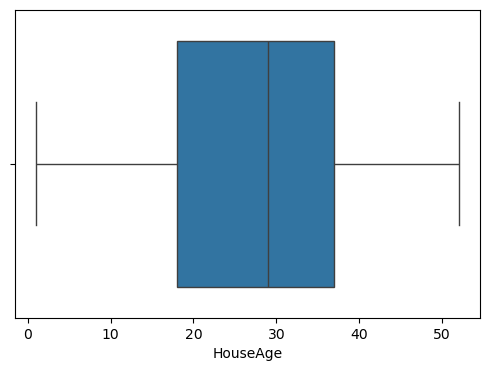

In [29]:
plt.figure(figsize= (6,4))
sns.boxplot(data= X, x= 'HouseAge')
plt.show()

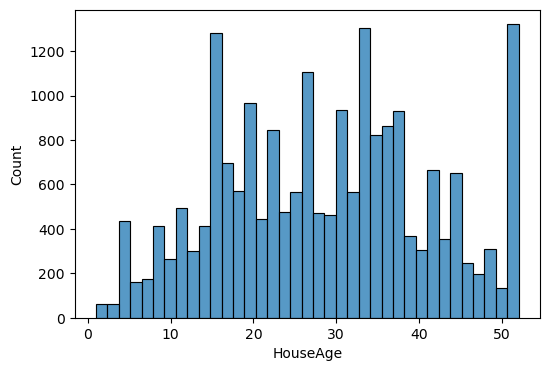

In [30]:
plt.figure(figsize= (6,4))
sns.histplot(data= X, x= 'HouseAge')
plt.show()

In [37]:
houseage_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

In [39]:
# Preprocessor:

preprocessor = ColumnTransformer([
    ('Median_Income', medinc_pipeline, ['MedInc']),
    ('HouseHold_Age',houseage_pipeline, ['HouseAge'])
])

##### 4) AveRooms:

In [42]:
X['AveRooms'].describe()

count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: AveRooms, dtype: float64

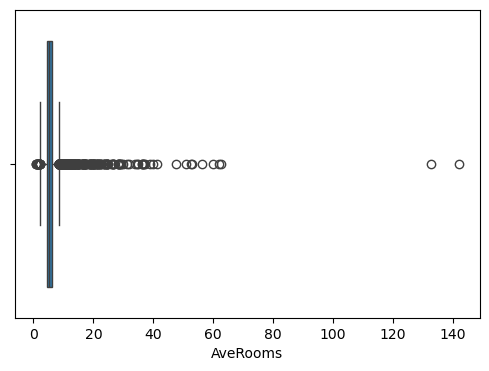

In [43]:
plt.figure(figsize= (6,4))
sns.boxplot(data= X, x= 'AveRooms')
plt.show()

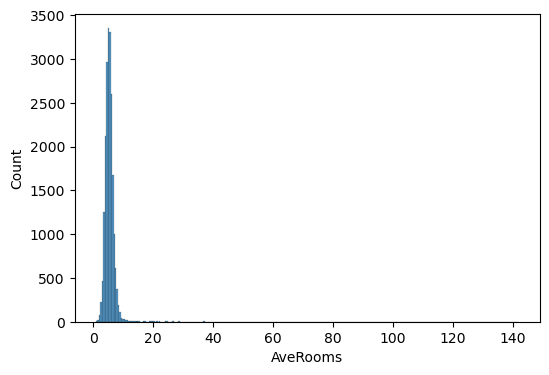

In [44]:
plt.figure(figsize= (6,4))
sns.histplot(data= X, x= 'AveRooms')
plt.show()

- From Boxplot and Histogram, we can see that 'AveRooms' feature has a lot of Outliers.
- Distribution seems normal but with a significantlly long Right Tail.

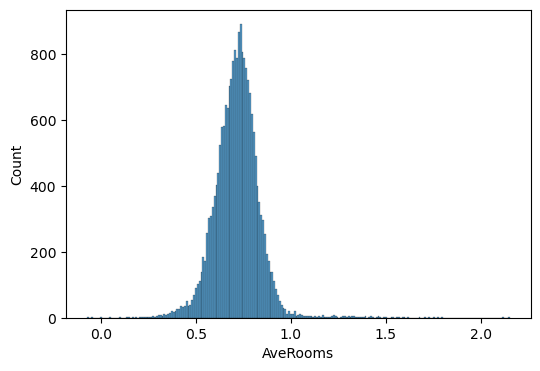

In [62]:
plt.figure(figsize= (6,4))
sns.histplot(data= X['AveRooms'].apply(np.log10))
plt.show()

In [63]:
averooms_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.log10)),
    ('scaler', StandardScaler())
])

In [66]:
# Preprocessor:

preprocessor = ColumnTransformer([
    ('Median_Income', medinc_pipeline, ['MedInc']),
    ('HouseHold_Age',houseage_pipeline, ['HouseAge']),
    ('Average_Rooms', averooms_pipeline, ['AveRooms'])
])

##### 5) AveBedrms:

In [67]:
X['AveBedrms'].describe()

count    20640.000000
mean         1.096675
std          0.473911
min          0.333333
25%          1.006079
50%          1.048780
75%          1.099526
max         34.066667
Name: AveBedrms, dtype: float64

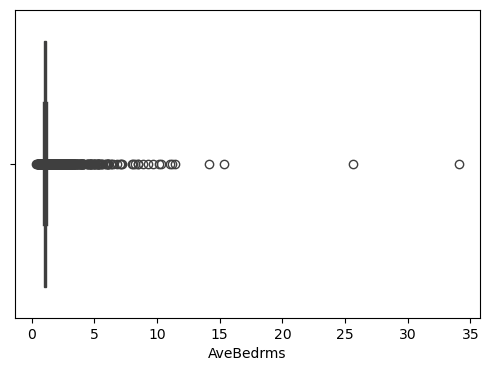

In [68]:
plt.figure(figsize= (6,4))
sns.boxplot(data= X, x= 'AveBedrms')
plt.show()

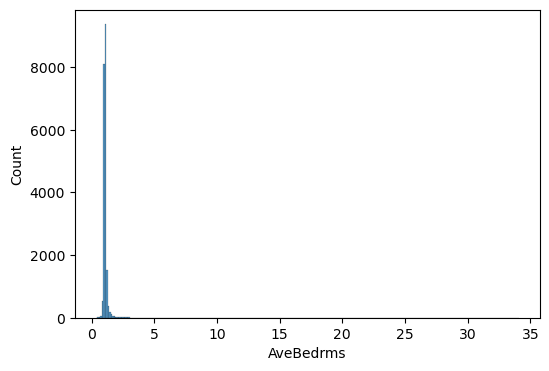

In [69]:
plt.figure(figsize= (6,4))
sns.histplot(data= X, x= 'AveBedrms')
plt.show()

- 'AveBedrms' feature has a lot of Outliers.
- Distribution has a significant long Right tail.

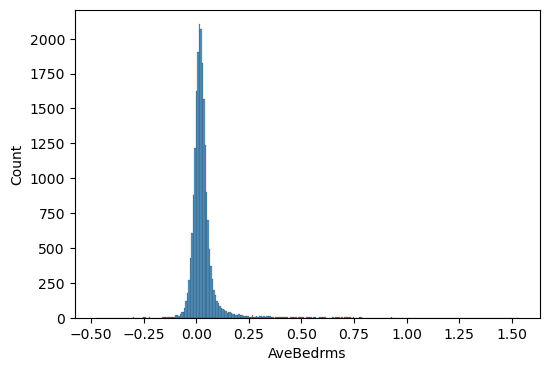

In [80]:
plt.figure(figsize= (6,4))
sns.histplot(data= X['AveBedrms'].apply(np.log10))
plt.show()

In [81]:
avebedrooms_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.log10)),
    ('scaler', StandardScaler())
])

In [82]:
# Preprocessor:

preprocessor = ColumnTransformer([
    ('Median_Income', medinc_pipeline, ['MedInc']),
    ('HouseHold_Age',houseage_pipeline, ['HouseAge']),
    ('Average_Rooms', averooms_pipeline, ['AveRooms']),
    ('Average_BedRooms', avebedrooms_pipeline, ['AveBedrms'])
])

##### 6) Population:

In [84]:
X['Population'].describe()

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: Population, dtype: float64

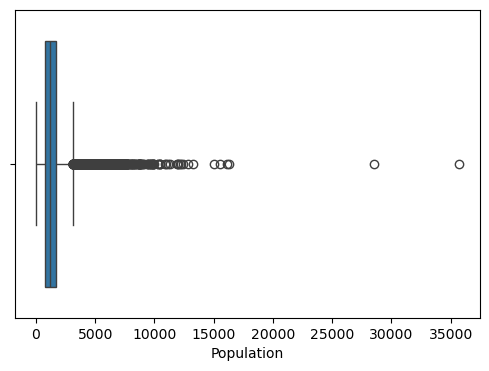

In [85]:
plt.figure(figsize= (6,4))
sns.boxplot(data=X, x= 'Population')
plt.show()

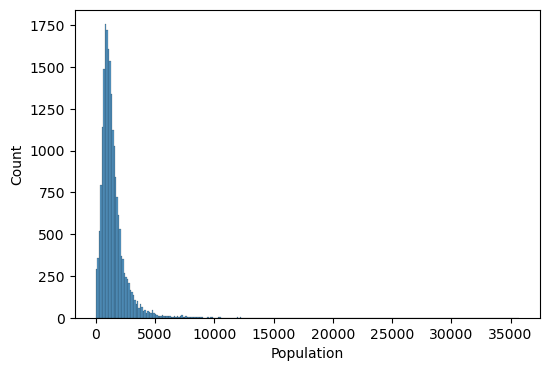

In [86]:
plt.figure(figsize= (6,4))
sns.histplot(data=X, x= 'Population')
plt.show()

- 'Population' feature has a lot of Outliers.
- Distribution has a long Right tail.

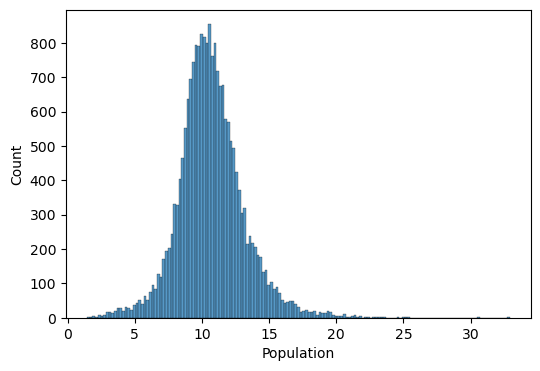

In [98]:
plt.figure(figsize= (6,4))
sns.histplot(data= X['Population'].apply(np.cbrt))
plt.show()

In [99]:
population_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.cbrt)),
    ('scaler', StandardScaler())
])

In [100]:
# Preprocessor:

preprocessor = ColumnTransformer([
    ('Median_Income', medinc_pipeline, ['MedInc']),
    ('HouseHold_Age',houseage_pipeline, ['HouseAge']),
    ('Average_Rooms', averooms_pipeline, ['AveRooms']),
    ('Average_BedRooms', avebedrooms_pipeline, ['AveBedrms']),
    ('Population', population_pipeline, ['Population'])
])

##### 7) AveOccup:

In [103]:
X['AveOccup'].describe()

count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

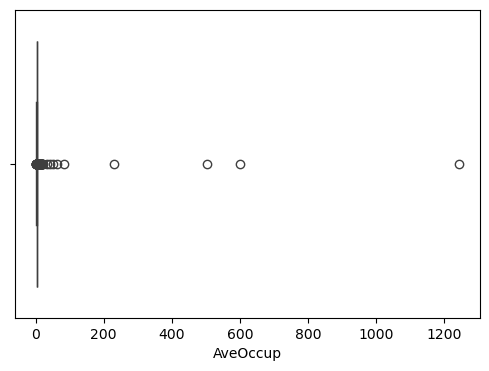

In [104]:
plt.figure(figsize= (6,4))
sns.boxplot(data=X, x= 'AveOccup')
plt.show()

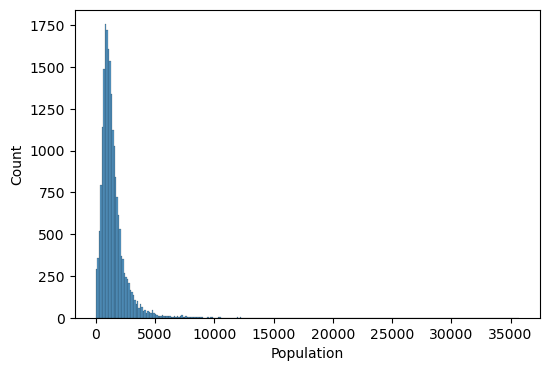

In [105]:
plt.figure(figsize= (6,4))
sns.histplot(data=X, x= 'Population')
plt.show()

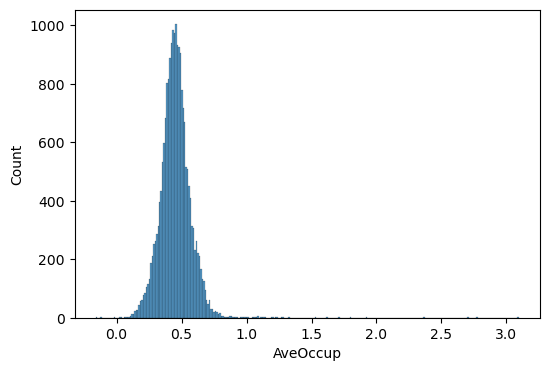

In [115]:
plt.figure(figsize= (6,4))
sns.histplot(data= X['AveOccup'].apply(np.log10))
plt.show()

In [116]:
aveoccupation_pipeline = Pipeline([
    ('transformation', FunctionTransformer(np.log10)),
    ('scaler', StandardScaler())
])

In [117]:
# Preprocessor:

preprocessor = ColumnTransformer([
    ('Median_Income', medinc_pipeline, ['MedInc']),
    ('HouseHold_Age',houseage_pipeline, ['HouseAge']),
    ('Average_Rooms', averooms_pipeline, ['AveRooms']),
    ('Average_BedRooms', avebedrooms_pipeline, ['AveBedrms']),
    ('Population', population_pipeline, ['Population']),
    ('Average_Occupation', aveoccupation_pipeline, ['AveOccup'])
])

##### 8) Latitude and Longitude:

In [122]:
X[['Latitude','Longitude']]

,Latitude,Longitude
0,37.88,-122.23
1,37.86,-122.22
2,37.85,-122.24
3,37.85,-122.25
4,37.85,-122.25
...,...,...
20635,39.48,-121.09
20636,39.49,-121.21
20637,39.43,-121.22
20638,39.43,-121.32


- As direct Latitude and Longitudes og Houses may not be very useful for model to predict House Price, we will use feature engineering to create some new features out of Latitude and Longitude.
    - Divide House Locations into Clusters.
    - Approximate distance of houses to Coast.
    - Interaction fetures between 'MedInc' and Latitude and Longitude (coastal or southern cities with higher income have pricier houses).

###### 1) Location Clustering:

In [124]:
class KMeansRegions(BaseEstimator, TransformerMixin):
    """
    Fits KMeans on longitude & latitude, returns a single column region_id.
    """
    
    def __init__(self, n_clusters= 8, random_state= 42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans= None

    def fit(self, X, y= None):
        """
        X: expected shape (n_samples, 2) -> [longitude, latitude]
        """
        self.kmeans = KMeans(n_clusters= self.n_clusters, random_state= self.random_state)
        self.kmeans.fit(X)
        return self

    def transform(self, X):
        return self.kmeans.predict(X).reshape(-1, 1)

###### 2) Distance to Coast:

In [129]:
def distance_to_coast(X):
    """
    Using Longitude to find Distance of Houses to Caost.
    Longitude of Westernmost CA coast approx is approximately: -124.35.
    """

    longitude = np.array(X)[:, 1]
    return np.abs(-124.35 - longitude).reshape(-1, 1)

###### 3) Interactio Terms:

In [137]:
def make_interaction_feature(col_name):
    """
    col_name is 'longitude' or 'latitude'
    """

    def interaction(X):
        """
        X = [MedInc, longitude] or [MedInc, latitude]
        """
        medinc = X[:, 0]
        coord = X[:, 1]

        return (medinc * coord).reshape(-1, 1)

    return FunctionTransformer(interaction, validate= True)

###### 4) Pipelines for Latitude / Longitude and all related Features:

In [131]:
# Scaling for Original Latitude and Longitude Features:

long_lat_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

In [132]:
# Distance to Coast:

distance_to_coast_pipeline = Pipeline([
    ('dist', FunctionTransformer(distance_to_coast, validate= True)),
    ('scaler', StandardScaler())
])

In [136]:
# Clustering:

region_cluster_pipeline = Pipeline([
    ('kmeans', KMeansRegions(n_clusters= 8, random_state= 42)),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore', sparse_output= False))
])

In [139]:
# interactions: MedInc * longitude and MedInc * latitude

income_lon_pipeline = Pipeline([
    ('interaction', make_interaction_feature(col_name= 'longitude')),
    ('scaler', StandardScaler())
])

income_lat_pipeline = Pipeline([
    ('interaction', make_interaction_feature(col_name= 'latitude')),
    ('scaler', StandardScaler())
])

###### 5) Final Preprocessor:

In [140]:
# Preprocessor:

preprocessor = ColumnTransformer([
    ('Median_Income', medinc_pipeline, ['MedInc']),
    ('HouseHold_Age',houseage_pipeline, ['HouseAge']),
    ('Average_Rooms', averooms_pipeline, ['AveRooms']),
    ('Average_BedRooms', avebedrooms_pipeline, ['AveBedrms']),
    ('Population', population_pipeline, ['Population']),
    ('Average_Occupation', aveoccupation_pipeline, ['AveOccup']),
    ('LonLat', long_lat_pipeline, ['Latitude','Longitude']),
    ('distcane_to_coast', distance_to_coast_pipeline, ['Latitude','Longitude']),
    ('region', region_cluster_pipeline, ['Latitude','Longitude']),
    ('Income_Latitude', income_lat_pipeline, ['MedInc','Latitude']),
    ('Income_Longitude', income_lon_pipeline, ['MedInc','Longitude'])
], remainder= 'drop')

#### 4) Train Test Split:

In [146]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [147]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512, 1)
(4128, 1)


#### 4) Model Buidling and Evaluation:

In [145]:
models = {
    'Linear Regression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas = (0.01, 0.1, 1, 5, 10, 25, 50, 100),
                        cv= 10,
                        scoring= 'r2'),
    'LassoCV': LassoCV(cv= 10, random_state= 42, max_iter= 10000),
    'ElasticNetCV': ElasticNetCV(l1_ratio= [0.001, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1], 
                            eps= 0.001, cv= 10, max_iter= 1000000)
}

In [148]:
results = {}

for name, model in models.items():

    pipe = Pipeline([
        ('Preprocessing', preprocessor),
        ('Model', model)
    ])

    pipe.fit(X_train, y_train) # Model Fitting

    y_pred = pipe.predict(X_test) # Predictions Using Model

    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    R2_Score = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': MAE,
        'RMSE': RMSE,
        'R2-Score': R2_Score
    }

C:\Users\shail\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\shail\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [149]:
results = pd.DataFrame(results).T.sort_values(by= 'R2-Score', ascending= False)
results

,MAE,RMSE,R2-Score
LassoCV,0.482487,0.664868,0.662663
ElasticNetCV,0.482487,0.664868,0.662663
RidgeCV,0.483303,0.665092,0.662435
Linear Regression,0.483366,0.665141,0.662386
